# Price Analysis

## Setup

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# import ast
# import numpy as np

## Load Data

In [2]:
sblush = pd.read_csv(r"../semi_cleaned_data/clean_single_blushes_v1.csv")

In [2]:
su_blush = pd.read_csv('../semi_cleaned_data/single_unique_blush.csv')

## Exploratory Data Analysis (EDA)

In [3]:
sblush.info()

<class 'pandas.DataFrame'>
RangeIndex: 1435 entries, 0 to 1434
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   shade_url          1435 non-null   str    
 1   brand              1435 non-null   str    
 2   product_name       1435 non-null   str    
 3   shade              1435 non-null   str    
 4   swatch_img_url     1435 non-null   str    
 5   swatch_alt         1435 non-null   str    
 6   description        1088 non-null   str    
 7   price              1435 non-null   float64
 8   standard_value     1435 non-null   float64
 9   standard_unit      1435 non-null   str    
 10  product_id         1435 non-null   int64  
 11  shade_id           1435 non-null   int64  
 12  product_image_url  1435 non-null   str    
 13  rgb_r              1435 non-null   int64  
 14  rgb_g              1435 non-null   int64  
 15  rgb_b              1435 non-null   int64  
 16  lab_L              1435 non-null   

In [4]:
sblush.head()

,shade_url,brand,product_name,shade,swatch_img_url,swatch_alt,description,price,standard_value,standard_unit,...,rgb_g,rgb_b,lab_L,lab_a,lab_b,rgb,lab,L_axis,b_axis,hex_color
0,https://www.ulta.com/p/trublend-skin-enhancer-...,CoverGirl,Trublend Skin Enhancer Balm Blush Stick,Bubblegum Pop,https://media.ultainc.com/i/ulta/2634527_sw?im...,Bubblegum Pop Trublend Skin Enhancer Balm Blus...,"cool, bright pink",12.99,5.95,g,...,126,180,69.10,54.69,-5.27,"255,126,180","69.1,54.69,-5.27",69.10,-5.27,#ff7eb4
1,https://www.ulta.com/p/trublend-skin-enhancer-...,CoverGirl,Trublend Skin Enhancer Balm Blush Stick,Candied Strawberry,https://media.ultainc.com/i/ulta/2652760_sw?im...,Candied Strawberry Trublend Skin Enhancer Balm...,bright red,12.99,5.95,g,...,52,58,44.38,55.71,30.35,"193,52,58","44.38,55.71,30.35",44.38,30.35,#c1343a
2,https://www.ulta.com/p/trublend-skin-enhancer-...,CoverGirl,Trublend Skin Enhancer Balm Blush Stick,Midnight Plum,https://media.ultainc.com/i/ulta/2652756_sw?im...,Midnight Plum Trublend Skin Enhancer Balm Blus...,deep berry,12.99,5.95,g,...,25,50,23.44,37.06,4.89,"105,25,50","23.44,37.06,4.89",23.44,4.89,#691932
3,https://www.ulta.com/p/trublend-skin-enhancer-...,CoverGirl,Trublend Skin Enhancer Balm Blush Stick,Nude Flush,https://media.ultainc.com/i/ulta/2634526_sw?im...,Nude Flush Trublend Skin Enhancer Balm Blush S...,nude pink,12.99,5.95,g,...,132,124,64.56,33.66,19.24,"222,132,124","64.56,33.66,19.24",64.56,19.24,#de847c
4,https://www.ulta.com/p/trublend-skin-enhancer-...,CoverGirl,Trublend Skin Enhancer Balm Blush Stick,Pink Sprinkle,https://media.ultainc.com/i/ulta/2652758_sw?im...,Pink Sprinkle Trublend Skin Enhancer Balm Blus...,warm pink,12.99,5.95,g,...,133,156,68.06,43.98,6.51,"242,133,156","68.06,43.98,6.51",68.06,6.51,#f2859c


In [7]:
sblush[["product_name", "brand", "price", "product_id", "shade_url"]]

1435

## Clean Data

In [ ]:
sblush[['product_id', 'price']].drop_duplicates() # get unique price for each product_id

,product_id,price
0,2049677,12.99
10,2034815,18.00
20,2012166,28.00
22,2057554,34.00
27,2007329,13.99
...,...,...
1405,2045180,34.00
1411,2037598,56.00
1417,2054165,15.50
1431,2045404,13.00


In [45]:
sblush.groupby(['brand', 'product_id', 'product_name', 'standard_value', 'standard_unit'], as_index=False)['price'].max()

,brand,product_id,product_name,standard_value,standard_unit,price
0,Alleyoop,77001487,Stack the Odds,7.94,g,20.0
1,Anastasia Beverly Hills,2026378,Cream Stick Blush with Brush Applicator,8.50,g,32.0
2,Anastasia Beverly Hills,2045615,Blurring Serum Blush,9.07,g,25.0
3,Anastasia Beverly Hills,2052290,Magic Touch Cream Blush & Lip Trio,3.00,g,38.0
4,Apieu,77004460,Juicy Pang Water Blush,8.50,g,12.0
...,...,...,...,...,...,...
241,jane iredale,2055446,ColorLuxe Liquid Blush,4.54,g,34.0
242,r.e.m. beauty,2032207,Eclipse Cheek & Lip Stick,7.37,g,26.0
243,r.e.m. beauty,2044063,Hypernova Satin Matte Blush,4.82,g,25.0
244,r.e.m. beauty,2057423,MÃ©lange Ã Trois Blush & Highlight Stick,5.95,g,29.0


### Check for duplicates

In [110]:
sblush[sblush[['product_id','standard_value']].duplicated()]

,shade_url,brand,product_name,shade,swatch_img_url,swatch_alt,description,price,standard_value,standard_unit,...,rgb_g,rgb_b,lab_L,lab_a,lab_b,rgb,lab,L_axis,b_axis,hex_color
1,https://www.ulta.com/p/trublend-skin-enhancer-...,CoverGirl,Trublend Skin Enhancer Balm Blush Stick,Candied Strawberry,https://media.ultainc.com/i/ulta/2652760_sw?im...,Candied Strawberry Trublend Skin Enhancer Balm...,bright red,12.99,5.95,g,...,52,58,44.38,55.71,30.35,"193,52,58","44.38,55.71,30.35",44.38,30.35,#c1343a
2,https://www.ulta.com/p/trublend-skin-enhancer-...,CoverGirl,Trublend Skin Enhancer Balm Blush Stick,Midnight Plum,https://media.ultainc.com/i/ulta/2652756_sw?im...,Midnight Plum Trublend Skin Enhancer Balm Blus...,deep berry,12.99,5.95,g,...,25,50,23.44,37.06,4.89,"105,25,50","23.44,37.06,4.89",23.44,4.89,#691932
3,https://www.ulta.com/p/trublend-skin-enhancer-...,CoverGirl,Trublend Skin Enhancer Balm Blush Stick,Nude Flush,https://media.ultainc.com/i/ulta/2634526_sw?im...,Nude Flush Trublend Skin Enhancer Balm Blush S...,nude pink,12.99,5.95,g,...,132,124,64.56,33.66,19.24,"222,132,124","64.56,33.66,19.24",64.56,19.24,#de847c
4,https://www.ulta.com/p/trublend-skin-enhancer-...,CoverGirl,Trublend Skin Enhancer Balm Blush Stick,Pink Sprinkle,https://media.ultainc.com/i/ulta/2652758_sw?im...,Pink Sprinkle Trublend Skin Enhancer Balm Blus...,warm pink,12.99,5.95,g,...,133,156,68.06,43.98,6.51,"242,133,156","68.06,43.98,6.51",68.06,6.51,#f2859c
5,https://www.ulta.com/p/trublend-skin-enhancer-...,CoverGirl,Trublend Skin Enhancer Balm Blush Stick,Radiant Peach,https://media.ultainc.com/i/ulta/2634528_sw?im...,Radiant Peach Trublend Skin Enhancer Balm Blus...,warm peach,12.99,5.95,g,...,116,93,65.39,51.34,38.40,"255,116,93","65.39,51.34,38.4",65.39,38.40,#ff745d
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1428,https://www.ulta.com/p/tinted-moisturizer-crea...,Laura Mercier,Tinted Moisturizer Cream Blush,Provence,https://media.ultainc.com/i/ulta/2594667_sw?im...,Provence Tinted Moisturizer Cream Blush,pale pink nude,33.00,15.00,g,...,135,115,61.80,20.51,20.01,"195,135,115","61.8,20.51,20.01",61.80,20.01,#c38773
1429,https://www.ulta.com/p/tinted-moisturizer-crea...,Laura Mercier,Tinted Moisturizer Cream Blush,Soleil,https://media.ultainc.com/i/ulta/2594674_sw?im...,Soleil Tinted Moisturizer Cream Blush,shimmering warm gold,33.00,15.00,g,...,154,79,67.45,12.67,46.64,"209,154,79","67.45,12.67,46.64",67.45,46.64,#d19a4f
1430,https://www.ulta.com/p/tinted-moisturizer-crea...,Laura Mercier,Tinted Moisturizer Cream Blush,Southbound,https://media.ultainc.com/i/ulta/2594668_sw?im...,Southbound Tinted Moisturizer Cream Blush,peachy pink,33.00,15.00,g,...,129,121,62.83,31.88,18.40,"214,129,121","62.83,31.88,18.4",62.83,18.40,#d68179
1433,https://www.ulta.com/p/superdewy-liquid-blush-...,Revolution Beauty,Superdewy Liquid Blush,You Got Me Blushing,https://media.ultainc.com/i/ulta/2583417_sw?im...,You Got Me Blushing Superdewy Liquid Blush,muted rose,7.00,14.17,g,...,101,103,57.57,46.73,21.69,"220,101,103","57.57,46.73,21.69",57.57,21.69,#dc6567


In [ ]:
# sblush[sblush.duplicated()] # double check for duplicates
sblush.loc[sblush['product_id']==2047076] # display all rows of a product_id

,shade_url,brand,product_name,shade,swatch_img_url,swatch_alt,description,price,standard_value,standard_unit,...,rgb_g,rgb_b,lab_L,lab_a,lab_b,rgb,lab,L_axis,b_axis,hex_color
1079,https://www.ulta.com/p/blush-rush-liquid-blush...,about-face,Blush Rush Liquid Blush,Front Runner,https://media.ultainc.com/i/ulta/2640157_sw?im...,Front Runner Blush Rush Liquid Blush,bright berry,18.0,3.50,ml,...,74,99,46.32,45.32,7.58,"180,74,99","46.32,45.32,7.58",46.32,7.58,#b44a63
1080,https://www.ulta.com/p/blush-rush-liquid-blush...,about-face,Blush Rush Liquid Blush,Grand Prix,https://media.ultainc.com/i/ulta/2630323_sw?im...,Grand Prix Blush Rush Liquid Blush,red brown,18.0,3.12,g,...,41,29,29.13,34.93,26.71,"123,41,29","29.13,34.93,26.71",29.13,26.71,#7b291d
1081,https://www.ulta.com/p/blush-rush-liquid-blush...,about-face,Blush Rush Liquid Blush,Hot Lap,https://media.ultainc.com/i/ulta/2630319_sw?im...,Hot Lap Blush Rush Liquid Blush,barbie pink,18.0,3.12,g,...,90,162,61.87,66.91,-5.81,"250,90,162","61.87,66.91,-5.81",61.87,-5.81,#fa5aa2
1082,https://www.ulta.com/p/blush-rush-liquid-blush...,about-face,Blush Rush Liquid Blush,In The Dust,https://media.ultainc.com/i/ulta/2630320_sw?im...,In The Dust Blush Rush Liquid Blush,rosy mauve,18.0,3.12,g,...,94,101,53.80,44.26,17.35,"204,94,101","53.8,44.26,17.35",53.80,17.35,#cc5e65
1083,https://www.ulta.com/p/blush-rush-liquid-blush...,about-face,Blush Rush Liquid Blush,Jump Start,https://media.ultainc.com/i/ulta/2630472_sw?im...,Jump Start Blush Rush Liquid Blush,vivid lilac,18.0,3.12,g,...,58,136,41.82,51.39,-22.11,"161,58,136","41.82,51.39,-22.11",41.82,-22.11,#a13a88
1084,https://www.ulta.com/p/blush-rush-liquid-blush...,about-face,Blush Rush Liquid Blush,Pit Stop,https://media.ultainc.com/i/ulta/2630321_sw?im...,Pit Stop Blush Rush Liquid Blush,orange peach,18.0,3.12,g,...,60,36,47.97,56.75,47.11,"208,60,36","47.97,56.75,47.11",47.97,47.11,#d03c24
1085,https://www.ulta.com/p/blush-rush-liquid-blush...,about-face,Blush Rush Liquid Blush,Rev It Up,https://media.ultainc.com/i/ulta/2640158_sw?im...,Rev It Up Blush Rush Liquid Blush,juicy watermelon,18.0,3.50,ml,...,109,106,60.90,47.39,24.73,"232,109,106","60.9,47.39,24.73",60.90,24.73,#e86d6a
1086,https://www.ulta.com/p/blush-rush-liquid-blush...,about-face,Blush Rush Liquid Blush,Starting Line,https://media.ultainc.com/i/ulta/2630322_sw?im...,Starting Line Blush Rush Liquid Blush,peachy pink,18.0,3.12,g,...,140,136,67.92,34.87,17.36,"233,140,136","67.92,34.87,17.36",67.92,17.36,#e98c88


In [ ]:
# edit standard_value
# sblush.loc[sblush['product_id']==2004095, "standard_value"] = 3
# sblush.loc[sblush['product_id']==2024399, 'standard_value'] = 7.5
# sblush.loc[sblush['product_id']==2056483, 'standard_value'] = 6
# sblush.loc[sblush['product_id']==2056377, 'standard_value'] = 5
# sblush.loc[sblush['product_id']==2045365, 'standard_value'] = 10
# sblush.loc[sblush['product_id']==13521181, 'standard_value'] = 4
# sblush.loc[sblush['product_id']==2032233, 'standard_value'] = 15
# sblush.loc[sblush['product_id']==2033817, 'standard_value'] = 9
# sblush.loc[sblush['product_id']==12620, 'standard_value'] = 4.25
# sblush.loc[sblush['product_id']==2042810, 'standard_value'] = 8
# sblush.loc[sblush['product_id']==2047076, 'standard_value'] = 3.25

In [ ]:
# if the duplicates need to be fixed 

# sblush.loc[sblush['product_id']==2047076, 'standard_unit'] = 'ml'
# sblush.loc[sblush['product_id']==2042810, 'standard_unit'] = 'ml'

In [106]:
sblush.loc[sblush['product_id']==2042810] 

,shade_url,brand,product_name,shade,swatch_img_url,swatch_alt,description,price,standard_value,standard_unit,...,rgb_g,rgb_b,lab_L,lab_a,lab_b,rgb,lab,L_axis,b_axis,hex_color
1092,https://www.ulta.com/p/maneater-satin-blush-ch...,Tarte,Maneater Satin Blush Cheek Plump,Cinnamon,https://media.ultainc.com/i/ulta/2617624_sw?im...,Cinnamon Maneater Satin Blush Cheek Plump,NaN,29.0,8.0,ml,...,69,56,39.47,32.54,23.78,"149,69,56","39.47,32.54,23.78",39.47,23.78,#954538
1093,https://www.ulta.com/p/maneater-satin-blush-ch...,Tarte,Maneater Satin Blush Cheek Plump,Dusty Rose,https://media.ultainc.com/i/ulta/2617623_sw?im...,Dusty Rose Maneater Satin Blush Cheek Plump,NaN,29.0,8.0,ml,...,126,109,59.19,23.59,19.80,"192,126,109","59.19,23.59,19.8",59.19,19.80,#c07e6d
1094,https://www.ulta.com/p/maneater-satin-blush-ch...,Tarte,Maneater Satin Blush Cheek Plump,Hot Pink,https://media.ultainc.com/i/ulta/2617622_sw?im...,Hot Pink Maneater Satin Blush Cheek Plump,NaN,29.0,8.0,ml,...,72,111,55.36,64.35,14.36,"234,72,111","55.36,64.35,14.36",55.36,14.36,#ea486f
1095,https://www.ulta.com/p/maneater-satin-blush-ch...,Tarte,Maneater Satin Blush Cheek Plump,Mauve,https://media.ultainc.com/i/ulta/2617932_sw?im...,Mauve Maneater Satin Blush Cheek Plump,NaN,29.0,8.0,ml,...,124,129,58.34,24.42,7.02,"185,124,129","58.34,24.42,7.02",58.34,7.02,#b97c81
1096,https://www.ulta.com/p/maneater-satin-blush-ch...,Tarte,Maneater Satin Blush Cheek Plump,Pink,https://media.ultainc.com/i/ulta/2617929_sw?im...,Pink Maneater Satin Blush Cheek Plump,NaN,29.0,8.0,ml,...,143,150,66.86,28.59,7.74,"216,143,150","66.86,28.59,7.74",66.86,7.74,#d88f96
1097,https://www.ulta.com/p/maneater-satin-blush-ch...,Tarte,Maneater Satin Blush Cheek Plump,Pink Beige,https://media.ultainc.com/i/ulta/2617928_sw?im...,Pink Beige Maneater Satin Blush Cheek Plump,NaN,29.0,8.0,ml,...,140,141,64.58,24.50,9.36,"204,140,141","64.58,24.5,9.36",64.58,9.36,#cc8c8d
1098,https://www.ulta.com/p/maneater-satin-blush-ch...,Tarte,Maneater Satin Blush Cheek Plump,Pink Coral,https://media.ultainc.com/i/ulta/2617931_sw?im...,Pink Coral Maneater Satin Blush Cheek Plump,NaN,29.0,8.0,ml,...,116,117,60.64,40.16,17.78,"219,116,117","60.64,40.16,17.78",60.64,17.78,#db7475
1099,https://www.ulta.com/p/maneater-satin-blush-ch...,Tarte,Maneater Satin Blush Cheek Plump,Pink Raspberry,https://media.ultainc.com/i/ulta/2617934_sw?im...,Pink Raspberry Maneater Satin Blush Cheek Plump,NaN,29.0,8.0,ml,...,59,75,39.77,43.16,12.78,"160,59,75","39.77,43.16,12.78",39.77,12.78,#a03b4b
1100,https://www.ulta.com/p/maneater-satin-blush-ch...,Tarte,Maneater Satin Blush Cheek Plump,Poppy,https://media.ultainc.com/i/ulta/2617933_sw?im...,Poppy Maneater Satin Blush Cheek Plump,NaN,29.0,8.0,ml,...,44,55,52.52,71.48,43.69,"240,44,55","52.52,71.48,43.69",52.52,43.69,#f02c37
1101,https://www.ulta.com/p/maneater-satin-blush-ch...,Tarte,Maneater Satin Blush Cheek Plump,Warm Pink,https://media.ultainc.com/i/ulta/2617930_sw?im...,Warm Pink Maneater Satin Blush Cheek Plump,NaN,29.0,8.0,ml,...,118,122,61.43,40.37,16.05,"221,118,122","61.43,40.37,16.05",61.43,16.05,#dd767a


In [ ]:
sblush.groupby('product_id')['standard_value'].nunique() # check for consistency in standard_value. make sure every product has the same size of its shade

product_id
10730       1
12620       1
820350      1
2003079     1
2004095     1
           ..
77002432    1
77004458    1
77004460    1
77004705    1
77004706    1
Name: standard_value, Length: 235, dtype: int64

### Filter out

In [88]:
su_blush = sblush.groupby(['brand', 'product_id', 'product_name', 'standard_value', 'standard_unit'], as_index=False)['price'].max() # as_index preserves the strcutre of original dataframe

In [ ]:
su_blush[su_blush['product_id'].duplicated()] # check for duplicates

,brand,product_id,product_name,standard_value,standard_unit,price


In [ ]:
su_blush = su_blush.drop_duplicates() # drop duplicates

### More Data Prepare

In [114]:
# 1. Define your bin edges (e.g., 0 to 15, 15 to 40, 40 up to infinity)
bins = [0, 20, 30, float('inf')]

# 2. Define labels for those bins
labels = ['Drug-store', 'Mid-range', 'High-end']

# 3. Create the new column using pd.cut
su_blush['price_tier'] = pd.cut(su_blush['price'], bins=bins, labels=labels)

In [119]:
# Check the results
print(f"Number of Products: {len(su_blush)}")
su_blush.head()

Number of Products: 235


,brand,product_id,product_name,standard_value,standard_unit,price,price_tier
0,Alleyoop,77001487,Stack the Odds,7.94,g,20.0,Drug-store
1,Anastasia Beverly Hills,2026378,Cream Stick Blush with Brush Applicator,8.50,g,32.0,High-end
2,Anastasia Beverly Hills,2045615,Blurring Serum Blush,9.07,g,25.0,Mid-range
3,Anastasia Beverly Hills,2052290,Magic Touch Cream Blush & Lip Trio,3.00,g,38.0,High-end
4,Apieu,77004460,Juicy Pang Water Blush,8.50,g,12.0,Drug-store


In [ ]:
# tiers = su_blush.groupby(['brand', 'price_tier']).size().unstack() # display how many product does each brand has in other tiers

In [126]:
su_blush['price_per_size'] = round(su_blush['price']/su_blush['standard_value'], 2)

In [127]:
su_blush.head()

,brand,product_id,product_name,standard_value,standard_unit,price,price_tier,price_per_size
0,Alleyoop,77001487,Stack the Odds,7.94,g,20.0,Drug-store,2.52
1,Anastasia Beverly Hills,2026378,Cream Stick Blush with Brush Applicator,8.50,g,32.0,High-end,3.76
2,Anastasia Beverly Hills,2045615,Blurring Serum Blush,9.07,g,25.0,Mid-range,2.76
3,Anastasia Beverly Hills,2052290,Magic Touch Cream Blush & Lip Trio,3.00,g,38.0,High-end,12.67
4,Apieu,77004460,Juicy Pang Water Blush,8.50,g,12.0,Drug-store,1.41


## Price Analysis

In [129]:
brand_analysis = su_blush.groupby(['brand', 'price_tier'])['price_per_size'].mean().unstack()

In [132]:
brand_analysis

price_tier,Drug-store,Mid-range,High-end
brand,,,
Alleyoop,2.52,NaN,NaN
Anastasia Beverly Hills,NaN,2.76,8.2150
Apieu,1.41,NaN,NaN
BLK/OPL,2.43,NaN,NaN
BOBBI BROWN,NaN,NaN,7.1125
...,...,...,...
florence by mills,2.05,NaN,NaN
fwee,4.34,NaN,NaN
jane iredale,NaN,NaN,8.9750


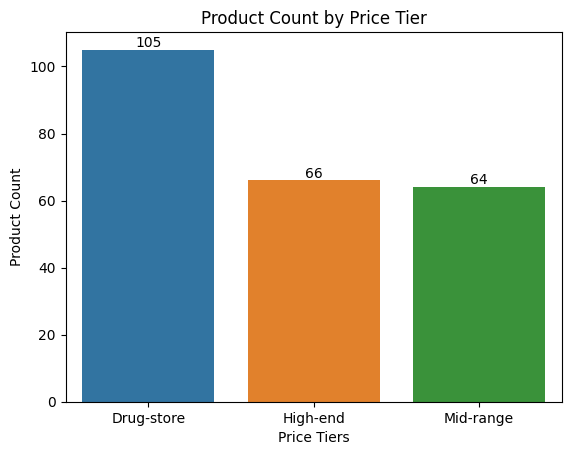

In [22]:
# Create the plot and assign it to a variable `ax`
ax = sns.countplot(data=su_blush, x='price_tier',hue='price_tier', legend=False) # returns a Matplotlib `Axes` object

# Add the labels ax.containers holds the bars created by the histogram
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=10)

plt.xlabel('Price Tiers')
plt.ylabel('Product Count')
plt.title('Product Count by Price Tier')
plt.show()

In [131]:
tier_summary = su_blush.groupby('price_tier').agg({
    'price': 'mean',
    'price_per_size': 'mean',
    'product_id': 'count' # How many products in this tier
}).rename(columns={'product_id': 'product_count'})
tier_summary

,price,price_per_size,product_count
price_tier,,,
Drug-store,12.327143,2.060476,105
Mid-range,26.639063,5.658125,64
High-end,38.333333,6.280909,66


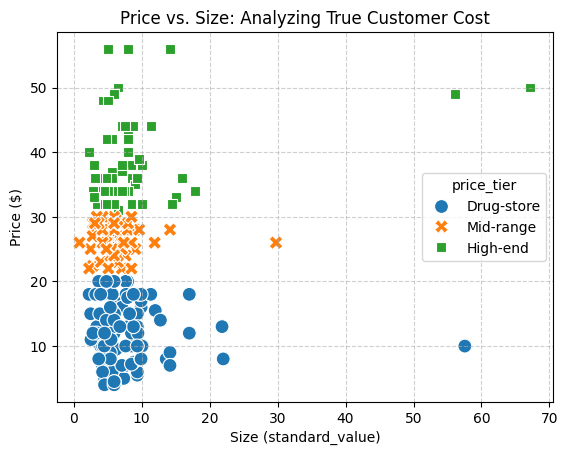

In [143]:
# Plot standard_value vs price, colored by price_tier
sns.scatterplot(
    data=su_blush, 
    x='standard_value', 
    y='price', 
    hue='price_tier', 
    style='price_tier',
    s=100
)

plt.title("Price vs. Size: Analyzing True Customer Cost")
plt.xlabel("Size (standard_value)")
plt.ylabel("Price ($)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

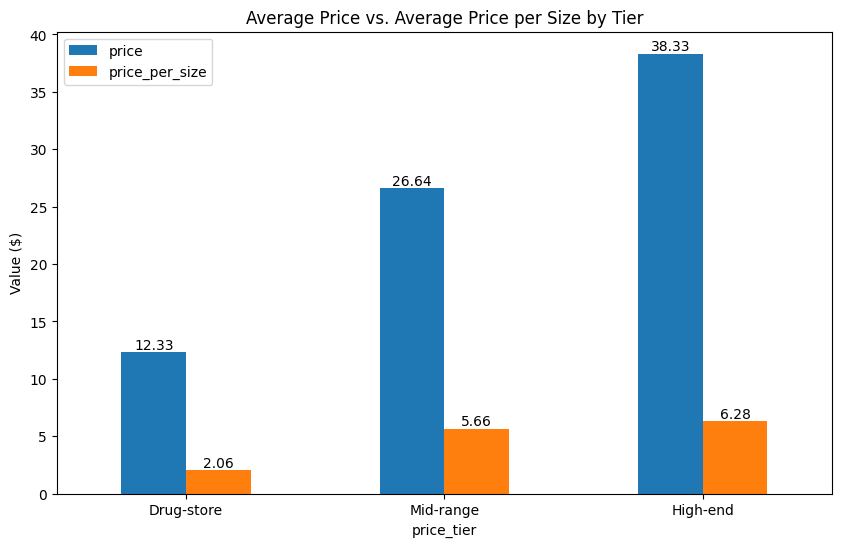

In [32]:
# Define the correct order
tier_order = ['Drug-store', 'Mid-range', 'High-end']

# Convert 'price_tier' to a categorical type with the specified order
su_blush['price_tier'] = pd.Categorical(
    su_blush['price_tier'], 
    categories=tier_order, 
    ordered=True
)

# Now, re-calculate and re-plot
tier_summary = su_blush.groupby('price_tier', observed=True)[['price', 'price_per_size']].mean()

# Create the plot and assign it to a variable `ax`
ax = tier_summary.plot(kind='bar', figsize=(10, 6), rot=0)
ax.bar_label(ax.containers[0], fmt='%.2f')
ax.bar_label(ax.containers[1], fmt='%.2f')

plt.title('Average Price vs. Average Price per Size by Tier')
plt.ylabel('Value ($)')
plt.show()

**Interpretation**

Even though High-end products are the most expensive on average, their price per gram is only slightly higher than Mid-end products.

In [36]:
su_blush.price_per_size.describe()

count    235.000000
mean       4.225574
std        3.373942
min        0.170000
25%        1.905000
50%        3.620000
75%        5.380000
max       30.590000
Name: price_per_size, dtype: float64

In [5]:
# 1. Create temporary tiers based on price_per_size using your distribution
# Using quantiles as an example to match your 25%/75% spread
bins = [0, 1.90, 5.38, float('inf')]
labels = ['Drug-store', 'Mid-range', 'High-end']
su_blush['new_tier'] = pd.cut(su_blush['price_per_size'], bins=bins, labels=labels)

# 2. Compare the old tiers vs. the new tiers
shift_check = pd.crosstab(su_blush['price_tier'], su_blush['new_tier'])

print(f"Migration of products between tiers:\n{shift_check}")
shift_check

Migration of products between tiers:
new_tier    Drug-store  Mid-range  High-end
price_tier                                 
Drug-store          55         46         4
High-end             3         31        32
Mid-range            1         41        22


new_tier,Drug-store,Mid-range,High-end
price_tier,,,
Drug-store,55,46,4
High-end,3,31,32
Mid-range,1,41,22


In [7]:
su_blush[['price_tier','new_tier']]

,price_tier,new_tier
0,Drug-store,Mid-range
1,High-end,Mid-range
2,Mid-range,Mid-range
3,High-end,High-end
4,Drug-store,Drug-store
...,...,...
230,High-end,High-end
231,Mid-range,Mid-range
232,Mid-range,Mid-range
233,Mid-range,Mid-range


## Export Data

In [ ]:
# su_blush.to_csv('../semi_cleaned_data/single_unique_blush.csv', index=False)
# sblush.to_csv('../semi_cleaned_data/clean_single_blushes_v2.csv', index=False)